# IS 4487 Assignment 5: Exploratory Data Analysis (EDA) with Stakeholder Framing

In this assignment, you will:
- Load and explore a hotel bookings dataset
- Identify stakeholder needs and frame your analysis around business goals
- Practice data summarization and visualization
- Draw insights that could lead to actionable business recommendations

## Why This Matters

These skills are essential for business majors and minors working in areas like marketing, operations, finance, or consulting. Understanding how to explore and communicate data-driven insights helps you make better decisions and contribute to real-world business outcomes.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_05_eda.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


## Dataset Description: Hotel Bookings

This dataset contains booking information for two types of hotels: a **city hotel** and a **resort hotel**. Each record corresponds to a single booking and includes various details about the reservation, customer demographics, booking source, and whether the booking was canceled.

**Source**: [GitHub - TidyTuesday: Hotel Bookings](https://github.com/rfordatascience/tidytuesday/blob/master/data/2020/2020-02-11/readme.md)

### Key Use Cases
- Understand customer booking behavior
- Explore factors related to cancellations
- Segment guests based on booking characteristics
- Compare city vs. resort hotel performance

### Data Dictionary

| Variable | Type | Description |
|----------|------|-------------|
| `hotel` | character | Hotel type: City or Resort |
| `is_canceled` | integer | 1 = Canceled, 0 = Not Canceled |
| `lead_time` | integer | Days between booking and arrival |
| `arrival_date_year` | integer | Year of arrival |
| `arrival_date_month` | character | Month of arrival |
| `stays_in_weekend_nights` | integer | Nights stayed on weekends |
| `stays_in_week_nights` | integer | Nights stayed on weekdays |
| `adults` | integer | Number of adults |
| `children` | integer | Number of children |
| `babies` | integer | Number of babies |
| `meal` | character | Type of meal booked |
| `country` | character | Country code of origin |
| `market_segment` | character | Booking source (e.g., Direct, Online TA) |
| `distribution_channel` | character | Booking channel used |
| `is_repeated_guest` | integer | 1 = Repeated guest, 0 = New guest |
| `previous_cancellations` | integer | Past booking cancellations |
| `previous_bookings_not_canceled` | integer | Past bookings not canceled |
| `reserved_room_type` | character | Initially reserved room type |
| `assigned_room_type` | character | Room type assigned at check-in |
| `booking_changes` | integer | Number of booking modifications |
| `deposit_type` | character | Deposit type (No Deposit, Non-Refund, etc.) |
| `agent` | character | Agent ID who made the booking |
| `company` | character | Company ID (if booking through company) |
| `days_in_waiting_list` | integer | Days on the waiting list |
| `customer_type` | character | Booking type: Contract, Transient, etc. |
| `adr` | float | Average Daily Rate (price per night) |
| `required_car_parking_spaces` | integer | Requested parking spots |
| `total_of_special_requests` | integer | Number of special requests made |
| `reservation_status` | character | Final status (Canceled, No-Show, Check-Out) |
| `reservation_status_date` | date | Date of the last status update |

This dataset is ideal for classification, segmentation, and trend analysis exercises.


## 1. Setup and Data Loading

Instructions:
- Import `pandas`, `seaborn`, and `matplotlib.pyplot`.
- Import data from the hotels dataset into a dataframe (in GitHub go to the DataSets folder and look for `hotels.csv`)
- Display the first few rows to confirm it loaded correctly.


In [7]:
# Your code to import libraries and load data goes here
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/refs/heads/main/data/2020/2020-02-11/hotels.csv')
df.head(5)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## 2. Stakeholder and Business Context

### Business framing:  

Every analysis should serve a decision-maker. Before you explore the data, identify who cares about hotel booking behavior and what they might want to know. Your analysis should be framed around those needs.

### Reflection:
1. Who are the key stakeholders for this dataset?
2. What goals might each stakeholder have?
3. What is a clear, specific business problem statement that this data can help answer?





### ✍️ Your Response: 🔧
1. The key stakeholders for this dataset are employees, executives, and more specifically, data analysts for the hotels.

2. The goals these stakeholders might have would be to understand customer behavior around when, where, and why they book hotels as well as why they might cancel them. They also might look for clustering to better understand characteristics of their customers that have similar behaviors.

3. We are looking to understand why customers cancel their bookings, and better predict when they might cancel in order to try to prevent customers that are identified with high risk of cancellation from cancelling.




## 3. Explore Data Structure and Quality

### Business framing:  

Before diving into analysis, analysts need to understand the shape and health of the data. Bad data leads to bad decisions.

### Do the following:
- Perform the following 3 checks to see the data quality:
  - Summary the data (e.g., `.info()`, `.describe()`)
  - Find the number of Null values
  - Find the number of duplicate row checks


In [8]:
# Add code here 🔧
df.info()
df.describe()
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

np.int64(31994)

### Reflection:
1. Name at least one structure issue you’ve found (e.g., missing values, formatting problems).
2. How can you fix this structural issue?

### ✍️ Your Response: 🔧
1. One issue I see is that in the 'company' column, almost all of the values are missing.

2. A way to fix this would be to drop this column completely, since it is too inconsistent to be used for analysis.



## 4. Univariate Analysis

### Business framing:  

Hotels care about trends like average stay length, customer mix, and pricing. A good EDA starts with understanding single variables and their distribution.

### Do the following:
- Select at least 3 individual variables to explore
- Use plots and summary methods (e.g. info(), describe(), etc)  to describe the distribution (hint: we are only looking at the values of one variable, so think of plots you've used in the past that DON'T compare 2 variables.)
- Focus on what matters from a business standpoint (e.g., pricing, cancellations, guest types)

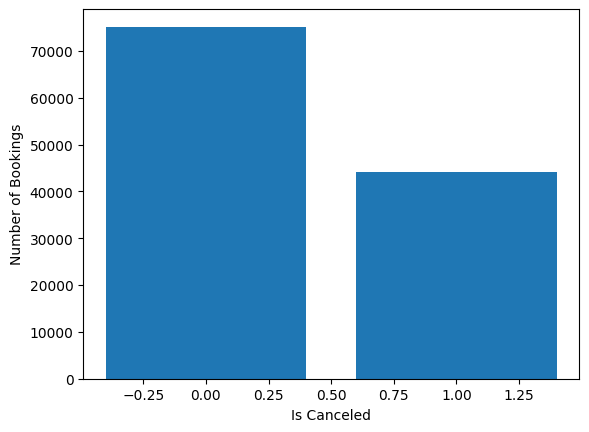

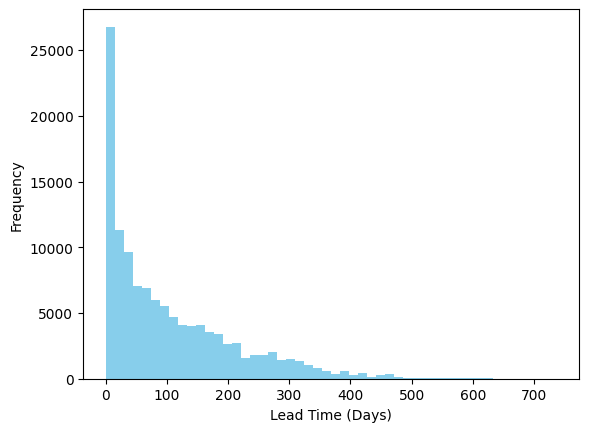

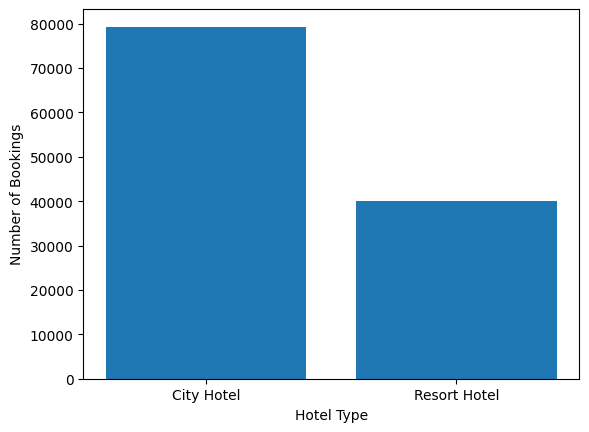

In [9]:
# Your code for univariate analysis (e.g., plots, value counts) 🔧
canceled_counts = df['is_canceled'].value_counts()
plt.bar(canceled_counts.index, canceled_counts.values)
plt.xlabel('Is Canceled')
plt.ylabel('Number of Bookings')
plt.show()
plt.hist(df['lead_time'], bins=50, color='skyblue')
plt.xlabel('Lead Time (Days)')
plt.ylabel('Frequency')
plt.show()
hotel_counts = df['hotel'].value_counts()
plt.bar(hotel_counts.index, hotel_counts.values)
plt.xlabel('Hotel Type')
plt.ylabel('Number of Bookings')
plt.show()

### Reflection:
1. Variable 1 – What did you explore and what did you find?
2. Variable 2 – What did you explore and what did you find?
3. Variable 3 – What did you explore and what did you find?

### ✍️ Your Response: 🔧
- **Variable 1 – Summary and Insights:** Out of 119,390 bookings, 75,166 were not canceled, and 44,224 were canceled. This indicates a substantial cancellation rate that hotel management needs to address.

- **Variable 2 – Summary and insights:** Lead time ranges from 0 to 737 days, with an average of approximately 104 days and a standard deviation of 106.86 days. The histogram likely shows a right-skewed distribution, meaning most bookings are made closer to the arrival date, but a significant number are made much further in advance. This insight is crucial for demand forecasting and managing inventory.

- **Variable 3 – Summary and insights:** The dataset includes two hotel types: City Hotel and Resort Hotel. There are 79,337 bookings for City Hotels and 40,053 for Resort Hotels. City Hotels account for a larger share of the total bookings, which could influence resource allocation and marketing strategies for each hotel type.

## 5. Bivariate Analysis

### Business framing:  

Stakeholders often ask: “What drives cancellations?” or “Do longer stays mean higher revenue?” Bivariate analysis helps you uncover those kinds of relationships.

### Do the following:
- Choose 2 relevant variable pairs (e.g., `lead_time` vs. `is_canceled`, or `adr` vs. `customer_type`)
- Use scatterplots, grouped bar plots, or boxplots to explore the relationships
- Interpret what these relationships could mean for the hotel business

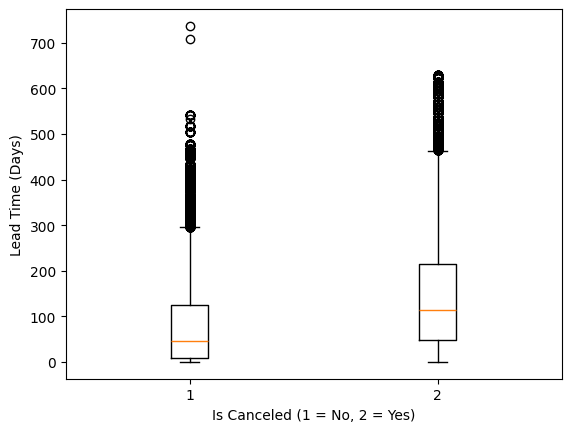

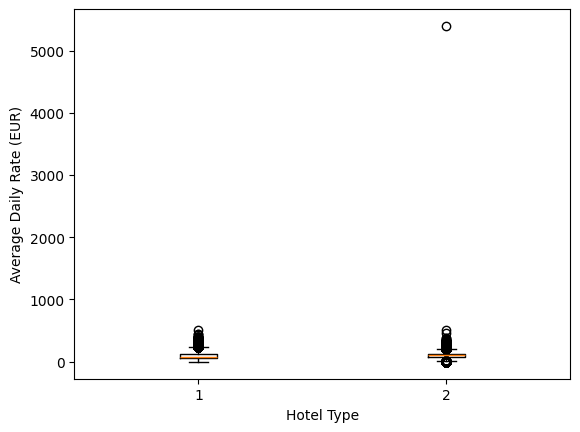

In [10]:
# Your code to analyze variable relationships (e.g., scatterplots, grouped bars) 🔧
canceled_lead_time = df[df['is_canceled'] == 1]['lead_time']
not_canceled_lead_time = df[df['is_canceled'] == 0]['lead_time']
plt.boxplot([not_canceled_lead_time, canceled_lead_time])
plt.xlabel('Is Canceled (1 = No, 2 = Yes)')
plt.ylabel('Lead Time (Days)')
plt.show()
city_hotel_adr = df[df['hotel'] == 'City Hotel']['adr']
resort_hotel_adr = df[df['hotel'] == 'Resort Hotel']['adr']
plt.boxplot([resort_hotel_adr, city_hotel_adr])
plt.xlabel('Hotel Type')
plt.ylabel('Average Daily Rate (EUR)')
plt.show()

### Reflection:
1. Relationship 1 – What did you analyze and what insights did you find?
2. Relationship 2 – What did you analyze and what insights did you find?

### ✍️ Your Response: 🔧
- **Relationship 1:** The boxplot comparing lead_time for canceled vs. not-canceled bookings reveals that bookings with longer lead times tend to have a higher median and wider distribution of lead times for canceled bookings. This suggests that guests who book further in advance are more likely to cancel their reservations, possibly due to changing plans or finding better deals. This insight is critical for the initial problem statement regarding predicting cancellations.

- **Relationship 2:** The boxplot comparing adr between City and Resort hotels shows distinct distributions. It's generally observed that Resort Hotels might have a slightly higher median ADR, or a wider range, potentially due to offering more amenities or being situated in more premium locations. City Hotels, while having more bookings, might have a more concentrated ADR around a lower median. Understanding these differences is vital for pricing strategies and revenue management specific to each hotel type.

## 6. Problem Complexity and Analytics Framing

### Business framing:  

Let’s say you found a strong trend — maybe high lead times predict cancellations, or certain channels bring repeat guests. What kind of problem is this?

- Choose one insight from your earlier analysis
- Reflect on:
  - What type of complexity this problem represents (e.g., variety, volume, variability)
  - What kind of analytics would help solve or explain it (descriptive, diagnostic, predictive, prescriptive)

### Reflection:
1. What was your selected insight?
2. What kind of complexity does it involve?
3. What type of analytics would help, and why?



### ✍️ Your Response: 🔧
1.  My selected insight was that when people book a hotel really far in advance (long lead time), they're more likely to cancel their reservation. This was pretty clear from looking at the box plot of lead times for canceled vs. non-canceled bookings.

2.  People cancel for all sorts of different reasons, so it's not always straightforward. Also, there are so many bookings, it's hard to keep track of every single one and guess who might cancel without some sort of analysis.

3.  I think predictive analytics would be really helpful here. We could use the data to build a model that tries to predict which bookings are most likely to be canceled. This would let the hotel managers know who to maybe check in with or offer incentives to, so they don't lose that booking.

## 7. Final Takeaways and Recommendations

### Business framing:  

Imagine you’re preparing for a stakeholder meeting. What would you highlight from your findings?

### Reflection:
- 1. What patterns or trends stood out?
- 2. How do they connect to stakeholder goals?
- 3. What recommendation would you make based on this analysis?
- 4. How does this relate to your customized learning outcome you created in canvas?



### ✍️ Your Response: 🔧
1.  A big thing is that about 37% of all bookings get canceled, which is a lot! Bookings made way ahead of time are definitely more prone to being canceled. City Hotels seem to get a lot more bookings than Resort Hotels. The average daily rate (ADR) for City and Resort hotels looks a bit different, which makes sense since they're different types of places.

2.  The cancellations really hurt revenue. If we can predict them, we can try to save some of that money. Understanding lead times helps with pricing and making sure we don't have too many empty rooms. Knowing that City Hotels get more bookings or how ADR differs can help them plan their ads better. They can also use info about cancellations to offer deals that might make people stick with their booking.

3.  Let's try to make a system that predicts which bookings are likely to be canceled, especially the ones with long lead times. That way, the hotel can reach out to those guests. For those long-lead-time bookings that seem risky, maybe send an email with a small discount or a free upgrade offer a few weeks before arrival to make them feel more committed.

4.  My learning outcomes focus on how I can use data analytics for accounting, and these same principles could apply in an audit. Instead of looking at the riskiest bookings that are likely to be cancelled, I might look at which transactions are the most likely to be incorrect or fraudulent.

## Submission Instructions

✅ **Before submitting:**
- Make sure all code cells are run and outputs are visible  
- All markdown questions are answered thoughtfully  
- Submit the assignment as an **HTML file** on Canvas


In [11]:
!jupyter nbconvert --to html "assignment_05_eda.ipynb"

[NbConvertApp] WARNING | pattern 'assignment_05_eda.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=True]
--execu